# CIFAR-10 model inspired by InceptionV3 Mixed 9 and Mixed 10

This corrected version fixes the ordering and naming problems in the previous notebook:

- every required function/class is imported **before** it is used;
- the model variable is consistently named `cifar10_inception_model`;
- there is no old `cnn` variable;
- `inputs` and `outputs` are created before `Model(...)`;
- `plot_model` is imported before it is called;
- the two Inception-C-inspired blocks are built as **nested Keras Models**, so `expand_nested=True` can display their internal four-branch structure.

We first build the architecture only. **Do not train yet.**


In [1]:
# ============================================================
# 1. IMPORTS
# Everything needed later is imported here BEFORE it is used.
# ============================================================

import os

# Select the PyTorch backend before importing Keras.
os.environ["KERAS_BACKEND"] = "torch"

import keras

from keras import Model

from keras.layers import (
    Input,
    Rescaling,
    Conv2D,
    BatchNormalization,
    Activation,
    MaxPooling2D,
    AveragePooling2D,
    Concatenate,
    GlobalAveragePooling2D,
    Dropout,
    Dense,

    # Data augmentation
    RandomFlip,
    RandomCrop,
    RandomErasing,
    ZeroPadding2D
)

# Used to generate the graphical architecture.
from keras.utils import plot_model

print("Keras version:", keras.__version__)
print("Backend:", keras.backend.backend())


Keras version: 3.15.1
Backend: torch


In [2]:
class TrainingPadCrop(keras.layers.Layer):
    def __init__(self, padding=4, crop_size=32, **kwargs):
        super().__init__(**kwargs)

        self.padding = ZeroPadding2D(
            padding=padding
        )

        self.crop = RandomCrop(
            height=crop_size,
            width=crop_size
        )

    def call(self, inputs, training=None):

        # During training:
        # 32x32 -> 40x40 -> random 32x32 crop
        if training:
            x = self.padding(inputs)
            x = self.crop(x, training=True)
            return x

        # During validation/test:
        # keep the original 32x32 image unchanged
        return inputs

In [3]:
data_augmentation = keras.Sequential(
    [
        TrainingPadCrop(
            padding=4,
            crop_size=32,
            name="augmentation_pad_crop",
        ),

        RandomFlip(
            mode="horizontal",
            name="augmentation_flip",
        ),

        RandomErasing(
            factor=(0.25, 0.25),
            value_range=(0, 255),
            name="augmentation_erasing",
        ),
    ],
    name="data_augmentation",
)

## 2. Reusable convolution helper

Inception repeatedly uses the same pattern:

`Conv2D → BatchNormalization → ReLU`

We put that repeated logic into one helper function.


In [4]:
def conv_bn_relu(x, filters, kernel_size, name):
    """
    Apply:
        Conv2D -> BatchNormalization -> ReLU

    x
        Input tensor.

    filters
        Number of output feature maps.

    kernel_size
        Convolution shape, e.g. (1,1), (3,3), (1,3), (3,1).

    name
        Prefix used to keep model.summary() and plot_model() readable.
    """

    # Learn visual filters.
    x = Conv2D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        use_bias=False,
        name=f"{name}_conv",
    )(x)

    # Stabilise the activations produced by the convolution.
    x = BatchNormalization(
        name=f"{name}_bn"
    )(x)

    # Add non-linearity.
    x = Activation(
        "relu",
        name=f"{name}_relu"
    )(x)

    return x


## 3. One compact Inception-C block

This follows the four top-level branches of InceptionV3 Mixed 9 / Mixed 10:

```text
                              INPUT
                                │
             ┌──────────────────┼──────────────────┬─────────────────┐
             │                  │                  │                 │
             ▼                  ▼                  ▼                 ▼
         BRANCH 1           BRANCH 2           BRANCH 3         BRANCH 4
            1×1                1×1                1×1             AvgPool
                               │                   │                 │
                         ┌─────┴─────┐             3×3              1×1
                         │           │              │
                        1×3         3×1        ┌────┴────┐
                         │           │         │         │
                         └─────┬─────┘        1×3       3×1
                               │                │         │
                               │                └────┬────┘
             │                 │                     │              │
             └─────────────────┴──────────┬──────────┴──────────────┘
                                          ▼
                                      CONCATENATE
                                          │
                                        OUTPUT
```

Our compact output is `256` channels:

`40 + 96 + 96 + 24 = 256`.


In [5]:
def build_inception_c_block(input_shape, name):
    """
    Build ONE reusable Inception-C-inspired block as a nested Keras Model.

    Making the block a Model is useful because:
    - we can reuse it;
    - plot_model(..., expand_nested=True) can show its internal structure;
    - Mixed 9 and Mixed 10 can have the same architecture but separate weights.
    """

    block_input = Input(
        shape=input_shape,
        name=f"{name}_input"
    )

    # ========================================================
    # BRANCH 1
    # INPUT -> 1x1 convolution
    # Output channels: 40
    # ========================================================
    branch1 = conv_bn_relu(
        block_input,
        filters=40,
        kernel_size=(1, 1),
        name=f"{name}_branch1",
    )

    # ========================================================
    # BRANCH 2
    # INPUT -> 1x1 -> split into 1x3 and 3x1 -> concatenate
    # Output channels: 48 + 48 = 96
    # ========================================================
    branch2_base = conv_bn_relu(
        block_input,
        filters=48,
        kernel_size=(1, 1),
        name=f"{name}_branch2_base",
    )

    branch2_1x3 = conv_bn_relu(
        branch2_base,
        filters=48,
        kernel_size=(1, 3),
        name=f"{name}_branch2_1x3",
    )

    branch2_3x1 = conv_bn_relu(
        branch2_base,
        filters=48,
        kernel_size=(3, 1),
        name=f"{name}_branch2_3x1",
    )

    branch2 = Concatenate(
        axis=-1,
        name=f"{name}_branch2_concat",
    )([
        branch2_1x3,
        branch2_3x1,
    ])

    # ========================================================
    # BRANCH 3
    # INPUT -> 1x1 -> 3x3 -> split 1x3 / 3x1 -> concatenate
    # Output channels: 48 + 48 = 96
    # ========================================================
    branch3 = conv_bn_relu(
        block_input,
        filters=56,
        kernel_size=(1, 1),
        name=f"{name}_branch3_reduce",
    )

    branch3 = conv_bn_relu(
        branch3,
        filters=48,
        kernel_size=(3, 3),
        name=f"{name}_branch3_3x3",
    )

    branch3_1x3 = conv_bn_relu(
        branch3,
        filters=48,
        kernel_size=(1, 3),
        name=f"{name}_branch3_1x3",
    )

    branch3_3x1 = conv_bn_relu(
        branch3,
        filters=48,
        kernel_size=(3, 1),
        name=f"{name}_branch3_3x1",
    )

    branch3 = Concatenate(
        axis=-1,
        name=f"{name}_branch3_concat",
    )([
        branch3_1x3,
        branch3_3x1,
    ])

    # ========================================================
    # BRANCH 4
    # INPUT -> AveragePool -> 1x1 convolution
    # Output channels: 24
    # ========================================================
    branch4 = AveragePooling2D(
        pool_size=(3, 3),
        strides=(1, 1),
        padding="same",
        name=f"{name}_branch4_avgpool",
    )(block_input)

    branch4 = conv_bn_relu(
        branch4,
        filters=24,
        kernel_size=(1, 1),
        name=f"{name}_branch4_1x1",
    )

    # ========================================================
    # FINAL FOUR-BRANCH CONCATENATION
    #
    # 40 + 96 + 96 + 24 = 256 channels
    # ========================================================
    block_output = Concatenate(
        axis=-1,
        name=f"{name}_output_concat",
    )([
        branch1,
        branch2,
        branch3,
        branch4,
    ])

    return Model(
        inputs=block_input,
        outputs=block_output,
        name=name,
    )


## 4. Build and test the two repeated Inception blocks

They have the **same architecture**, but they are two different Keras model objects and therefore learn **different weights**.

The first receives `8×8×128` and produces `8×8×256`.

The second receives `8×8×256` and again produces `8×8×256`.


In [6]:
# First block: input has 128 channels.
inception_c_1 = build_inception_c_block(
    input_shape=(8, 8, 128),
    name="inception_c_1",
)

# Second block: input now has 256 channels.
inception_c_2 = build_inception_c_block(
    input_shape=(8, 8, 256),
    name="inception_c_2",
)

print("Block 1 output shape:", inception_c_1.output_shape)
print("Block 2 output shape:", inception_c_2.output_shape)

# Expected:
# Block 1 output shape: (None, 8, 8, 256)
# Block 2 output shape: (None, 8, 8, 256)


Block 1 output shape: (None, 8, 8, 256)
Block 2 output shape: (None, 8, 8, 256)


## 5. Build the complete CIFAR-10 model

The small stem reduces the CIFAR image:

`32×32×3 → 16×16×64 → 8×8×128`

Then the two Inception-inspired blocks process the `8×8` feature maps.


In [7]:
# ============================================================
# INPUT
# ============================================================

inputs = Input(
    shape=(32, 32, 3),
    name="cifar10_input",
)

# ------------------------------------------------------------
# DATA AUGMENTATION
# Applied only during training.
# ------------------------------------------------------------
x = data_augmentation(inputs)

# ------------------------------------------------------------
# NORMALISATION
# 0...255 -> 0...1
# ------------------------------------------------------------
x = Rescaling(
    1.0 / 255,
    name="rescaling",
)(x)


# ============================================================
# SMALL CIFAR STEM
# ============================================================

x = conv_bn_relu(
    x,
    filters=32,
    kernel_size=(3, 3),
    name="stem_conv1",
)

x = conv_bn_relu(
    x,
    filters=64,
    kernel_size=(3, 3),
    name="stem_conv2",
)

# 32x32 -> 16x16
x = MaxPooling2D(
    pool_size=(2, 2),
    name="stem_pool1",
)(x)

x = conv_bn_relu(
    x,
    filters=128,
    kernel_size=(3, 3),
    name="stem_conv3",
)

# 16x16 -> 8x8
x = MaxPooling2D(
    pool_size=(2, 2),
    name="stem_pool2",
)(x)


# ============================================================
# TWO INCEPTION-C-INSPIRED BLOCKS
# ============================================================

x = inception_c_1(x)
x = inception_c_2(x)


# ============================================================
# CLASSIFICATION HEAD
# ============================================================

# 8x8x256 -> 256
x = GlobalAveragePooling2D(
    name="global_average_pool",
)(x)

# Regularisation before final classification.
x = Dropout(
    0.30,
    name="dropout",
)(x)

# CIFAR-10 has 10 classes.
outputs = Dense(
    10,
    activation="softmax",
    name="predictions",
)(x)


# ============================================================
# FINAL MODEL
# ============================================================

cifar10_inception_model = Model(
    inputs=inputs,
    outputs=outputs,
    name="cifar10_inception_model",
)


/home/bm/formation/deeplearning/deeplearning1/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:431: UserWarning: `build()` was called on layer 'augmentation_pad_crop', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


## 6. Inspect the model before training

First use `summary()` for the textual structure.

Then use `plot_model()` for the graphical structure.

Because the Inception blocks are nested Keras models, `expand_nested=True` should expose their internal branches.


Model: "cifar10_inception_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cifar10_input (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv1_conv (Conv2D)        │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv1_bn                   │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv1_relu (Activation)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv2_conv (Conv2D)        │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv2_bn                   │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv2_relu (Activation)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_pool1 (MaxPooling2D)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv3_conv (Conv2D)        │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv3_bn                   │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv3_relu (Activation)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_pool2 (MaxPooling2D)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_c_1 (Functional)      │ (None, 8, 8, 256)      │        74,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_c_2 (Functional)      │ (None, 8, 8, 256)      │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pool             │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267,946 (1.02 MB)

 Trainable params: 265,866 (1.01 MB)

 Non-trainable params: 2,080 (8.12 KB)

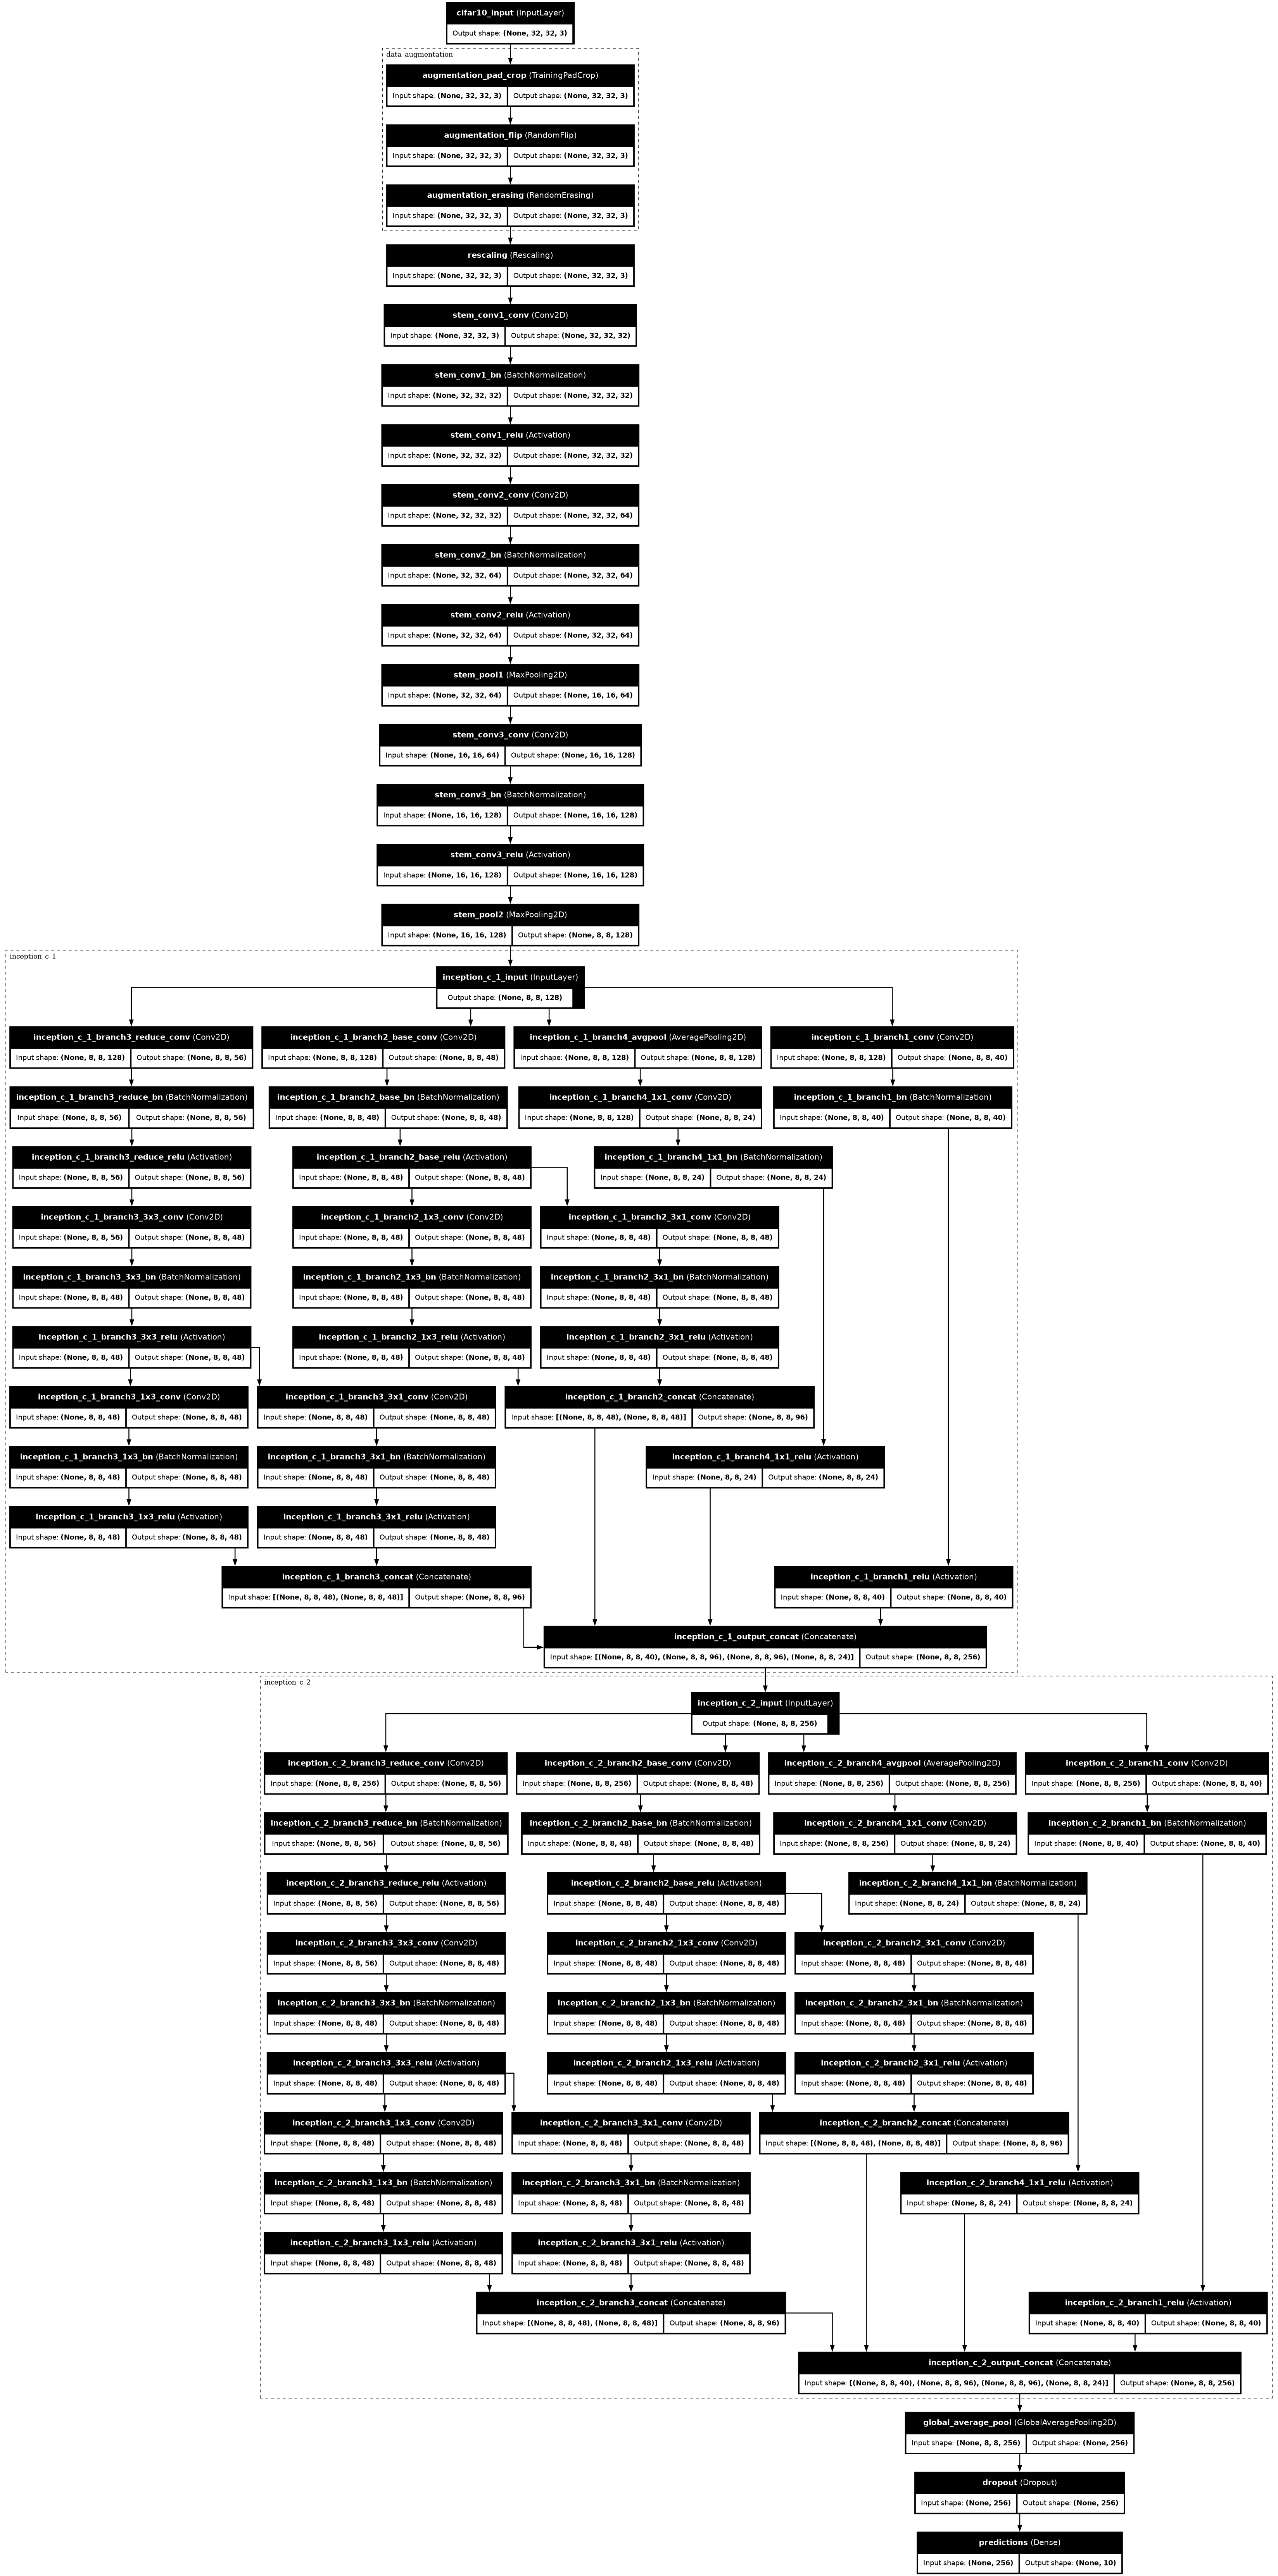

In [8]:
# Text representation.
cifar10_inception_model.summary()

# Graphical representation.
plot_model(
    cifar10_inception_model,
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=90,
)


## 7. Compile only — do not train yet

At this point we only verify that the model can be constructed and compiled.

After checking the `summary()` and graphical diagram, the next step is to choose the training configuration deliberately.


In [9]:
cifar10_inception_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("Model built and compiled successfully.")


Model built and compiled successfully.


In [10]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    min_delta=0.001,
    patience=7,
    restore_best_weights=True,
)

model_checkpoint = ModelCheckpoint(
    "cifar10_inception_best.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
)

callbacks = [
    early_stopping,
    model_checkpoint,
]

In [11]:
# ============================================================
# LOAD AND SPLIT CIFAR-10
# ============================================================

from keras.datasets import cifar10
from sklearn.model_selection import train_test_split


# CIFAR-10 provides:
# - 50,000 training images
# - 10,000 untouched test images
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()


# Split the original 50,000 training images into:
# - 40,000 training images
# - 10,000 validation images
#
# The test set remains untouched until final evaluation.
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.20,
    random_state=1,
)


# Verify that the split is exactly what we expect.
print("Training:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

Training: (40000, 32, 32, 3) (40000, 1)
Validation: (10000, 32, 32, 3) (10000, 1)
Test: (10000, 32, 32, 3) (10000, 1)


In [12]:
sample = x_train[:4]

print(
    "Training augmentation:",
    data_augmentation(sample, training=True).shape
)

print(
    "Validation augmentation:",
    data_augmentation(sample, training=False).shape
)

Training augmentation: torch.Size([4, 32, 32, 3])
Validation augmentation: torch.Size([4, 32, 32, 3])


In [13]:
history = cifar10_inception_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=256,
    callbacks=callbacks,
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.3978 - loss: 1.6194

I0000 00:00:1789567002.995036  176028 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789567003.040637  176028 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 156ms/step - accuracy: 0.3978 - loss: 1.6194 - val_accuracy: 0.1437 - val_loss: 3.2746
Epoch 2/20


I0000 00:00:1789567004.051006  176028 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 147ms/step - accuracy: 0.5609 - loss: 1.2199 - val_accuracy: 0.1409 - val_loss: 3.2565
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step - accuracy: 0.6248 - loss: 1.0452 - val_accuracy: 0.3972 - val_loss: 2.4151
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 150ms/step - accuracy: 0.6701 - loss: 0.9322 - val_accuracy: 0.6415 - val_loss: 1.0507
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step - accuracy: 0.6979 - loss: 0.8503 - val_accuracy: 0.5110 - val_loss: 1.5611
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 149ms/step - accuracy: 0.7199 - loss: 0.7939 - val_accuracy: 0.7170 - val_loss: 0.8206
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 147ms/step - accuracy: 0.7426 - loss: 0.7398 - val_accuracy: 0.6700 - val_loss: 0.9694
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step - accuracy: 0.7537 - loss: 0.7024 - val_accuracy: 0.6156 - val_loss: 1.2414
Epoch 9/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 147ms/step - accuracy: 0.7642 - loss: 0.6760 - val

In [14]:
test_loss, test_accuracy = cifar10_inception_model.evaluate(
    x_test,
    y_test,
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.7971 - loss: 0.6274


In [15]:
history = cifar10_inception_model.fit(
    x_train,
    y_train,

    validation_data=(
        x_val,
        y_val,
    ),

    epochs=20,

    # IMPORTANT:
    # use the same batch size as your previous CIFAR experiment
    # if we want a fair comparison.
    batch_size=256,

    callbacks=callbacks,
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 147ms/step - accuracy: 0.8283 - loss: 0.4933 - val_accuracy: 0.7480 - val_loss: 0.8391
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 149ms/step - accuracy: 0.8338 - loss: 0.4784 - val_accuracy: 0.7214 - val_loss: 0.8888
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 147ms/step - accuracy: 0.8354 - loss: 0.4683 - val_accuracy: 0.7718 - val_loss: 0.7293
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 146ms/step - accuracy: 0.8411 - loss: 0.4535 - val_accuracy: 0.7715 - val_loss: 0.7465
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.8416 - loss: 0.4575 - val_accuracy: 0.7155 - val_loss: 1.0059
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.8460 - loss: 0.4417 - val_accuracy: 0.7901 - val_loss: 0.6746
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.8510 - loss: 0.4303 - val_accuracy: 0.7829 - val_loss: 0.7002
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.8501 - loss: 0.425

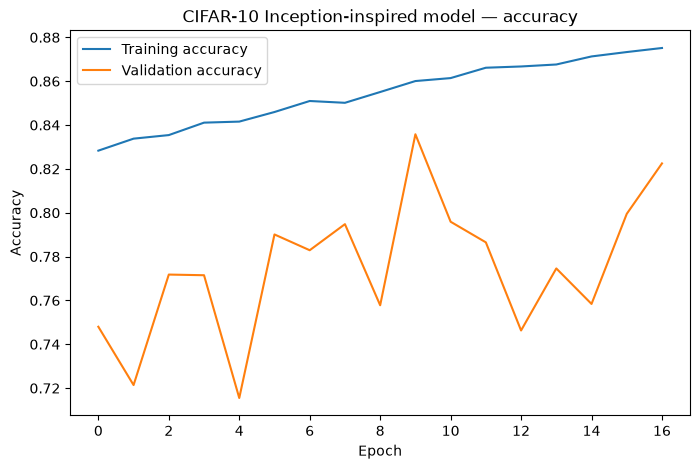

In [16]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training accuracy",
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CIFAR-10 Inception-inspired model — accuracy")
plt.legend()
plt.show()

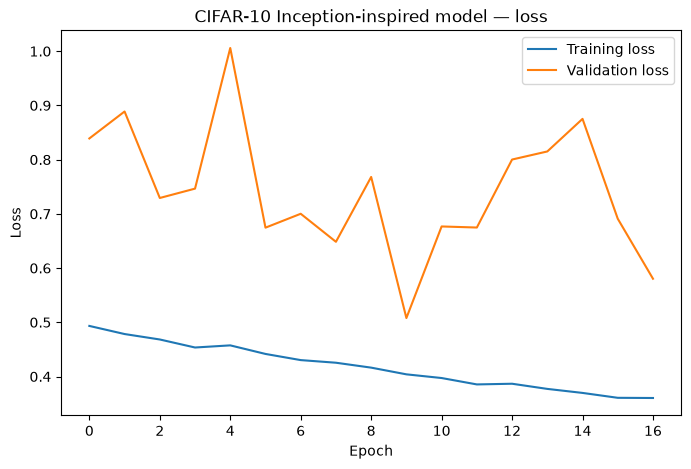

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training loss",
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CIFAR-10 Inception-inspired model — loss")
plt.legend()
plt.show()

In [18]:
test_loss, test_accuracy = cifar10_inception_model.evaluate(
    x_test,
    y_test,
    verbose=1,
)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8290 - loss: 0.5274
Test loss:     0.5274
Test accuracy: 0.8290
